# **Experiment_6C**

### Silhouette Method (Clustering Evaluation)

Given the following clustered dataset:

- **Cluster 1:** A(1,2), B(2,3)  
- **Cluster 2:** C(8,7), D(9,8)

Using the **Silhouette Method**, calculate the silhouette score for each point by computing:

- **Intra-cluster distance (a):** Average distance of a point to other points in the same cluster  
- **Nearest-cluster distance (b):** Average distance of a point to points in the nearest other cluster  

Then compute the silhouette score using the formula:

S=b-a/max(a,b)

Finally, determine the **overall average silhouette score** and **interpret** whether the clustering is good or not.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Data
points = {
    "A": np.array([1.0, 2.0]),
    "B": np.array([2.0, 3.0]),
    "C": np.array([8.0, 7.0]),
    "D": np.array([9.0, 8.0]),
}

In [3]:
cluster1 = ["A", "B"]
cluster2 = ["C", "D"]

In [4]:
clusters = {
    1: cluster1,
    2: cluster2
}

In [5]:
# Euclidean distance function
def euclidean(p, q):
    return np.sqrt(np.sum((p - q) ** 2))

In [6]:
# Compute silhouette for each point
# a = avg distance to points in same cluster
# b = min(avg distance to points in other clusters)
rows = []

for cid, members in clusters.items():
    for name in members:
        p = points[name]

        # a: intra-cluster avg distance
        same_cluster = [m for m in members if m != name]
        if len(same_cluster) == 0:
            a = 0.0
        else:
            a = np.mean([euclidean(p, points[m]) for m in same_cluster])

        # b: nearest other cluster avg distance
        other_cluster_ids = [k for k in clusters.keys() if k != cid]
        b_values = []
        for ocid in other_cluster_ids:
            others = clusters[ocid]
            b_values.append(np.mean([euclidean(p, points[m]) for m in others]))
        b = min(b_values)

        # silhouette
        s = (b - a) / max(a, b) if max(a, b) != 0 else 0.0

        rows.append([name, cid, a, b, s])

df = pd.DataFrame(rows, columns=["Point", "Cluster", "a (intra)", "b (nearest)", "Silhouette S"])
df["a (intra)"] = df["a (intra)"].round(4)
df["b (nearest)"] = df["b (nearest)"].round(4)
df["Silhouette S"] = df["Silhouette S"].round(4)

print(df)
print("\nAverage Silhouette Score =", round(df["Silhouette S"].mean(), 4))

  Point  Cluster  a (intra)  b (nearest)  Silhouette S
0     A        1     1.4142       9.3012        0.8480
1     B        1     1.4142       7.9067        0.8211
2     C        2     1.4142       7.9067        0.8211
3     D        2     1.4142       9.3012        0.8480

Average Silhouette Score = 0.8346


In [7]:
# Interpretation
avg_s = df["Silhouette S"].mean()
if avg_s > 0.7:
    print("Interpretation: Excellent clustering (well separated).")
elif avg_s > 0.5:
    print("Interpretation: Good clustering.")
elif avg_s > 0.25:
    print("Interpretation: Weak clustering (some overlap).")
else:
    print("Interpretation: Poor clustering (wrong grouping likely).")

Interpretation: Excellent clustering (well separated).


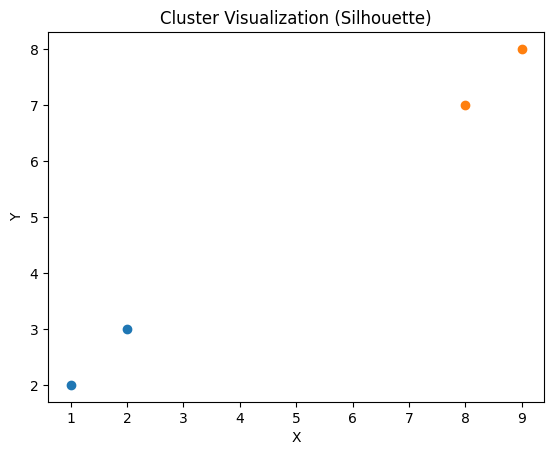

In [10]:
# Data points
cluster1 = np.array([[1,2], [2,3]])
cluster2 = np.array([[8,7], [9,8]])

# Plot
plt.figure()

plt.scatter(cluster1[:,0], cluster1[:,1])
plt.scatter(cluster2[:,0], cluster2[:,1])

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Cluster Visualization (Silhouette)")

plt.show()

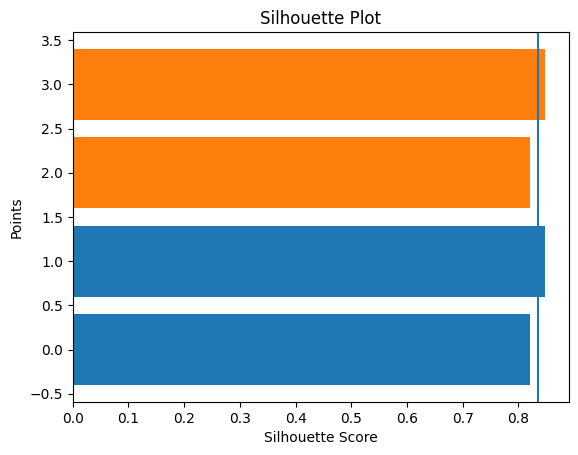

Average Silhouette Score = 0.8346


In [11]:
# Given Silhouette Scores
points = ["A", "B", "C", "D"]
scores = [0.8480, 0.8211, 0.8211, 0.8480]
clusters = [1, 1, 2, 2]

# Convert to numpy array
scores = np.array(scores)
clusters = np.array(clusters)

plt.figure()

y_lower = 0
for cluster in np.unique(clusters):
    cluster_scores = scores[clusters == cluster]
    cluster_scores.sort()
    size = len(cluster_scores)

    y_upper = y_lower + size

    plt.barh(range(y_lower, y_upper), cluster_scores)

    y_lower = y_upper

plt.axvline(x=np.mean(scores))
plt.xlabel("Silhouette Score")
plt.ylabel("Points")
plt.title("Silhouette Plot")

plt.show()

print("Average Silhouette Score =", round(np.mean(scores), 4))